# Module Imports

In [15]:
import scipy.io as sio
import pandas as pd
import numpy as np
import os
import torch
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if project_root not in sys.path:

    sys.path.insert(0, project_root)

print("Project root:", project_root)

print(sys.path)

from data_classes.decomposition import Extract_Features
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    cohen_kappa_score
)

import io
import contextlib

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.cm as cm

import time

import platform
import subprocess

Project root: /Users/kanwarsingh/Desktop/AI/acoustic_signal_classification
['/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages']


# Loading Data

In [2]:
# load & preprocess
P2_data = sio.loadmat('../../data/phase2_data_20220215.mat')
P2_samples = pd.DataFrame(P2_data['x'].T)
P2_labels  = pd.DataFrame(P2_data['y'].T, columns=['y'])
P2_df = pd.concat([P2_samples, P2_labels], axis=1)
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

P2_df = P2_df.drop(index=bad_indices, errors='ignore')
P2_df = P2_df.dropna()

shuffled_df = P2_df.sample(frac=1, random_state=42).reset_index(drop=True)
P2_df_X = shuffled_df.iloc[:, :-1]
P2_df_Y = shuffled_df.iloc[:, -1]

In [3]:
P2_raw = Extract_Features(P2_df_X, P2_df_Y, feature='raw')
print(P2_raw.get_samples().shape, P2_raw.get_labels().shape)

(8229, 4800) (8229,)


## Data Distribution

### Full Dataset Distribution

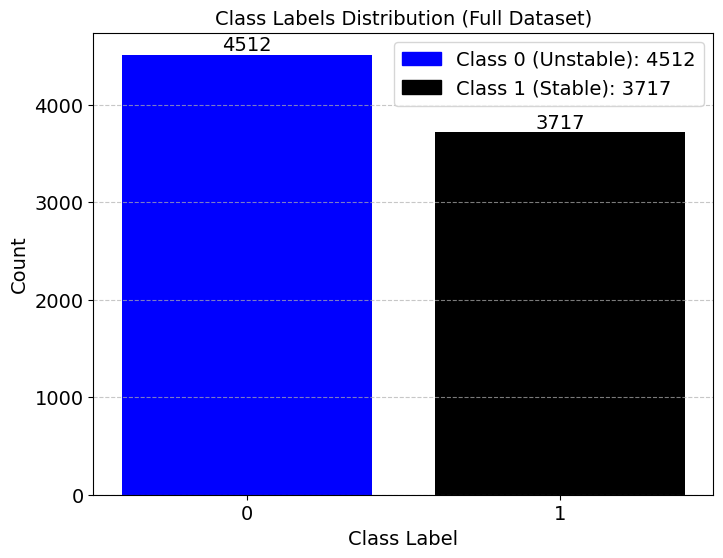

In [4]:
label_counts = P2_df_Y.value_counts().sort_index()

plt.figure(figsize=(8, 6))

colors = ['blue' if x == 0 else 'black' for x in label_counts.index]
bars = plt.bar(label_counts.index.astype(int), label_counts.values, color=colors)

plt.xlabel('Class Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Class Labels Distribution (Full Dataset)', fontsize=14)
plt.xticks(label_counts.index.astype(int), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# actual count on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom',
        fontsize=14
    )

# legend with actual counts
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label=f'Class 0 (Unstable): {label_counts.get(0, 0)}'),
    Patch(facecolor='black', edgecolor='black', label=f'Class 1 (Stable): {label_counts.get(1, 0)}')
]
plt.legend(handles=legend_elements, fontsize=14)

plt.show()

### Waveform Overlay

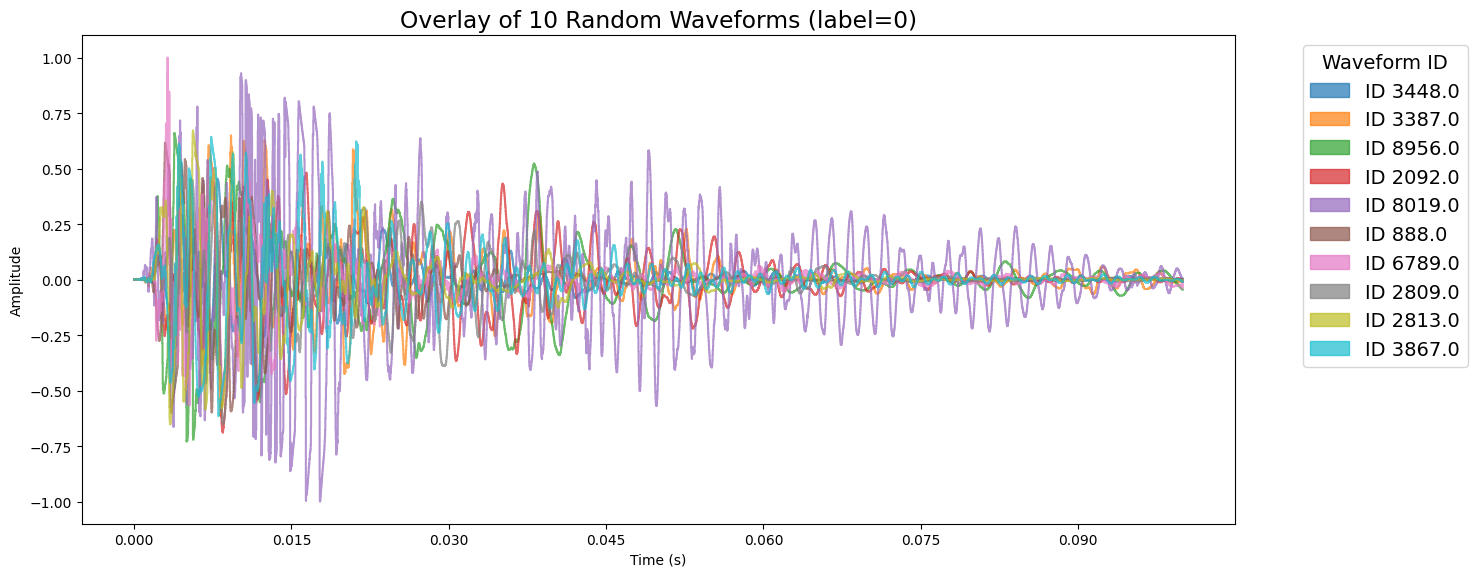

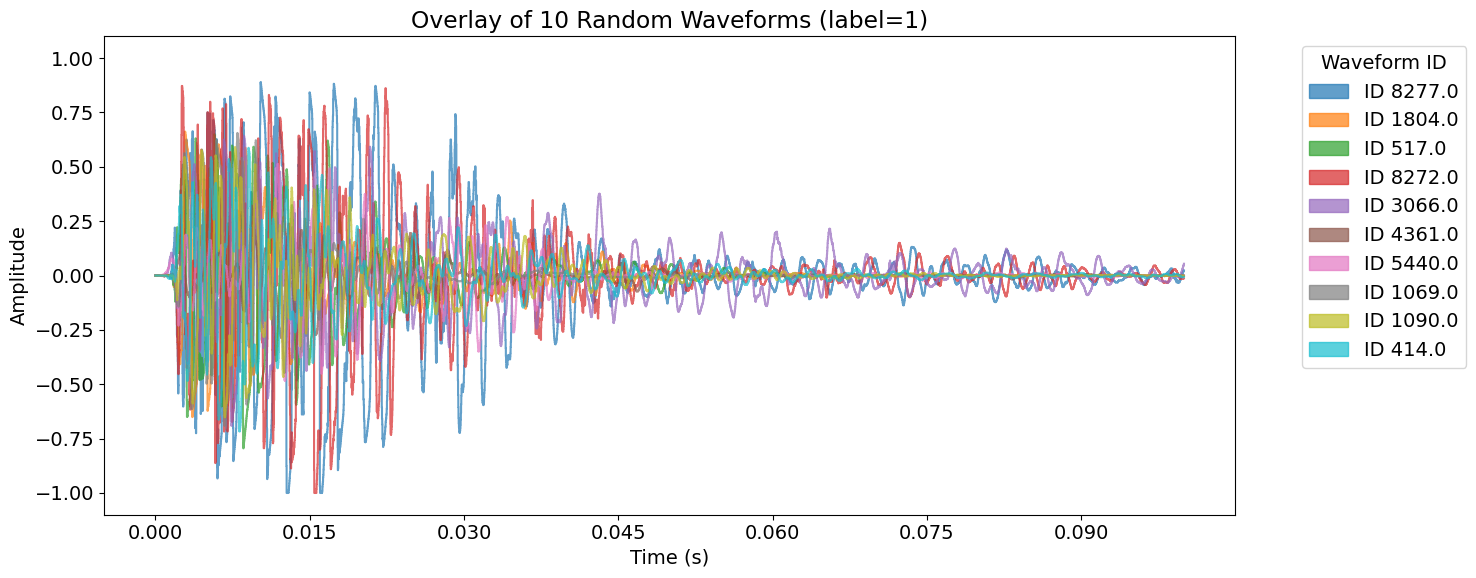

In [5]:
P2_sr = 48000
samples = P2_df[P2_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')
    
plt.rcParams['font.size'] = 14

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
samples = P2_df[P2_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Train, Test, Val Distribution for Epoch cutoff

In [6]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

# 80% training, 20% temporary validation/test set
train_val_idx, val_test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all

)

# Split the remaining 20% equally: 10% validation, 10% test

val_idx, test_idx = train_test_split(
    val_test_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_all[val_test_idx]

)

In [7]:
# distribution of class labels in train, validation, and test sets
train_labels = y_all[train_val_idx]
val_labels = y_all[val_idx]
test_labels = y_all[test_idx]

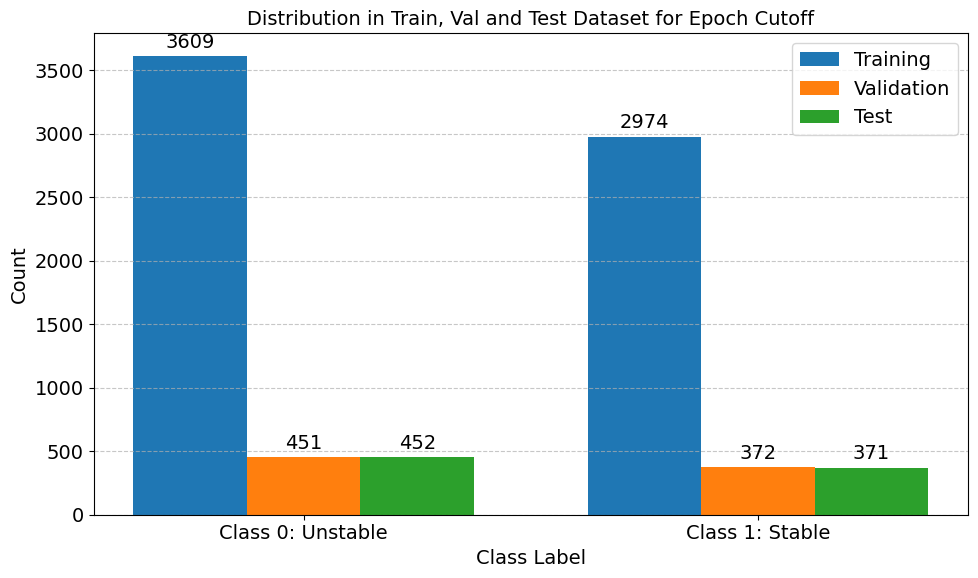

In [8]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
val_classes, val_counts = np.unique(val_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
val_count_dict = dict(zip(val_classes, val_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
val_class_counts = [val_count_dict.get(0, 0), val_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
val_bars = plt.bar(x, val_class_counts, width=bar_width, label="Validation")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train, Val and Test Dataset for Epoch Cutoff", fontsize=14)
plt.xticks(x, ["Class 0: Unstable", "Class 1: Stable"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + val_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, val_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


### Train and Test Distribution for Model Evaluation

In [9]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)

In [10]:
train_labels = y_all[train_idx]
test_labels = y_all[test_idx]

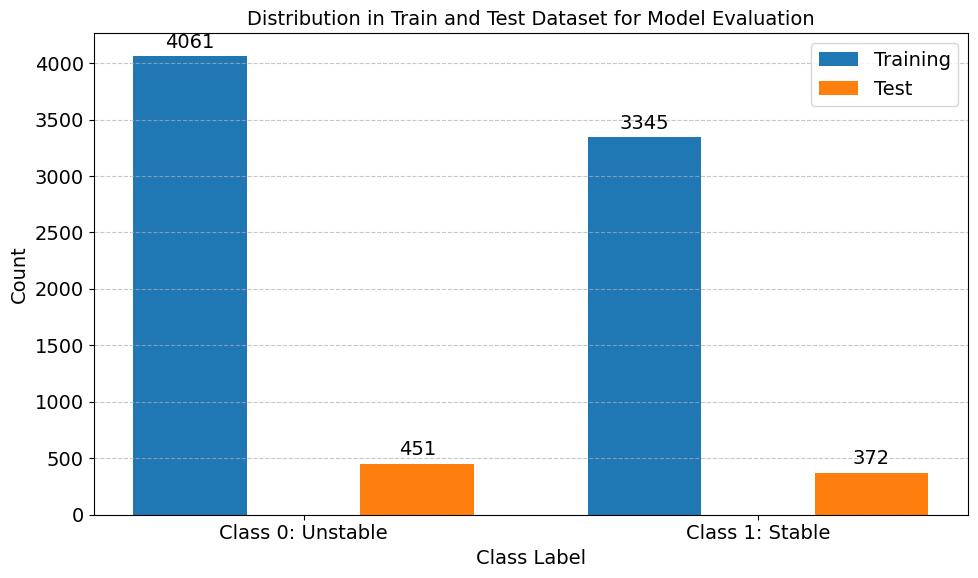

In [11]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train and Test Dataset for Model Evaluation", fontsize=14)
plt.xticks(x, ["Class 0: Unstable", "Class 1: Stable"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


## Prepare ROC Dataframe

In [12]:
roc_df = pd.DataFrame(columns=[

    "model_name","model","ev_pct","hidden","accuracy","roc_auc","fpr","tpr",

    "roc_thresholds","cohen_kappa","device_name","processor","ram_gb",

    "training_time_sec","single_inference_ms_mean","single_inference_ms_p95",

    "throughput_samples_sec","real_time_limit_ms","real_time_feasible"

])

roc_df

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible


## Inference Helpers

In [13]:
def run_command(command):
    try:
        return subprocess.check_output(command, shell=True, text=True).strip()
    except Exception:
        return "Unknown"


def get_device_info(device_str):
    processor = run_command("sysctl -n machdep.cpu.brand_string")
    if processor in ["", "Unknown"]:
        processor = run_command("sysctl -n hw.model")
    if processor in ["", "Unknown"]:
        processor = platform.processor() or platform.machine()
    ram_bytes = run_command("sysctl -n hw.memsize")
    try:
        ram_gb = round(int(ram_bytes) / (1024**3), 2)
    except Exception:
        ram_gb = np.nan
    if device_str == "mps":
        device_name = f"Apple Metal GPU ({processor})"
    elif device_str == "cuda":
        device_name = torch.cuda.get_device_name(0)
    else:
        device_name = f"CPU ({processor})"
    return {"device_name": device_name, "processor": processor, "ram_gb": ram_gb}


def synchronize_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


def get_batch_inputs(batch):
    if isinstance(batch, (tuple, list)):
        return batch[0]
    if isinstance(batch, dict):
        for key in ["x", "X", "input", "inputs", "features"]:
            if key in batch:
                return batch[key]
    return batch


def prepare_input(x):
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    x = x.float()
    if x.ndim == 1:
        x = x.unsqueeze(0)
    return x.reshape(x.shape[0], -1)


def benchmark_inference(model, test_loader, device_str, warmup_runs=50, timed_runs=300):
    device = torch.device(device_str)
    model = model.to(device)
    model.eval()
    batch = next(iter(test_loader))
    batch_x = prepare_input(get_batch_inputs(batch)).to(device)
    single_x = batch_x[:1]

    with torch.inference_mode():
        for _ in range(warmup_runs):
            _ = model(single_x)
        synchronize_device(device)
        single_times_ms = []

        for _ in range(timed_runs):
            synchronize_device(device)
            start = time.perf_counter()
            _ = model(single_x)
            synchronize_device(device)
            single_times_ms.append((time.perf_counter() - start) * 1000)

        for _ in range(warmup_runs):
            _ = model(batch_x)

        synchronize_device(device)
        batch_times_ms = []

        for _ in range(timed_runs):
            synchronize_device(device)
            start = time.perf_counter()
            _ = model(batch_x)
            synchronize_device(device)
            batch_times_ms.append((time.perf_counter() - start) * 1000)

    single_times_ms = np.array(single_times_ms)
    batch_times_ms = np.array(batch_times_ms)
    mean_batch_time_sec = np.mean(batch_times_ms) / 1000

    return {
        "single_inference_ms_mean": float(np.mean(single_times_ms)),
        "single_inference_ms_p95": float(np.percentile(single_times_ms, 95)),
        "throughput_samples_sec": float(batch_x.shape[0] / mean_batch_time_sec),
    }

def benchmark_sklearn_pipeline(pipeline,X_test,warmup_runs=50,timed_runs=300):
    single_x = X_test[:1]
    for _ in range(warmup_runs):
        pipeline.predict_proba(single_x)
    single_times_ms = []
    for _ in range(timed_runs):
        start = time.perf_counter()
        pipeline.predict_proba(single_x)
        single_times_ms.append((time.perf_counter()-start)*1000)
    for _ in range(warmup_runs):
        pipeline.predict_proba(X_test)
    batch_times_ms = []
    for _ in range(timed_runs):
        start = time.perf_counter()
        pipeline.predict_proba(X_test)
        batch_times_ms.append((time.perf_counter()-start)*1000)
    single_times_ms = np.array(single_times_ms)
    batch_times_ms = np.array(batch_times_ms)
    mean_batch_time_sec = np.mean(batch_times_ms)/1000
    return {
        "single_inference_ms_mean":float(np.mean(single_times_ms)),
        "single_inference_ms_p95":float(np.percentile(single_times_ms,95)),
        "throughput_samples_sec":float(len(X_test)/mean_batch_time_sec)
    }

def get_cnn_batch_inputs(batch):

    if isinstance(batch,(tuple,list)):

        return batch[0]

    if isinstance(batch,dict):

        for key in ["x","X","input","inputs","features"]:

            if key in batch:

                return batch[key]

    return batch

def benchmark_cnn_inference(model,test_loader,device_str,warmup_runs=50,timed_runs=300):

    device = torch.device(device_str)

    model = model.to(device)

    model.eval()

    batch = next(iter(test_loader))

    batch_x = get_cnn_batch_inputs(batch)

    if not torch.is_tensor(batch_x):

        batch_x = torch.tensor(batch_x,dtype=torch.float32)

    batch_x = batch_x.float().to(device)

    single_x = batch_x[:1]

    with torch.inference_mode():

        for _ in range(warmup_runs):

            _ = model(single_x)

        synchronize_device(device)

        single_times_ms = []

        for _ in range(timed_runs):

            synchronize_device(device)

            start = time.perf_counter()

            _ = model(single_x)

            synchronize_device(device)

            single_times_ms.append((time.perf_counter()-start)*1000)

        for _ in range(warmup_runs):

            _ = model(batch_x)

        synchronize_device(device)

        batch_times_ms = []

        for _ in range(timed_runs):

            synchronize_device(device)

            start = time.perf_counter()

            _ = model(batch_x)

            synchronize_device(device)

            batch_times_ms.append((time.perf_counter()-start)*1000)

    single_times_ms = np.array(single_times_ms)

    batch_times_ms = np.array(batch_times_ms)

    mean_batch_time_sec = np.mean(batch_times_ms)/1000

    return {

        "single_inference_ms_mean":float(np.mean(single_times_ms)),

        "single_inference_ms_p95":float(np.percentile(single_times_ms,95)),

        "throughput_samples_sec":float(batch_x.shape[0]/mean_batch_time_sec)

    }

# Classical Experiments

In [ ]:
# === PCA EV sweep with fixed nb_hidden {256,128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)

explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [128, 64, 32]   # fixed hidden sizes
batch_size = 32
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.1, random_state=42, stratify=y_all
)

results = []

device_str = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    # PCA features via Extract_Features
    P2_PCA = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P2_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds, test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P2_PCA.get_samples()
    y = P2_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    # SVM baseline
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))

    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc * 100,   # store as percentage number
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    # Only MLP 2-layer and 3-layer
    for h in hidden_grid:


        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP", "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P1.pth")

            # Train
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                loops.train(
                    model=model,
                    model_path=model_path,
                    train_loader=train_loader,
                    val=False,
                    val_loader=None,
                    batch_size=batch_size,
                    lr=1e-3,
                    weight_decay=0,
                    optim="adam",
                    epochs=epochs,
                )


            # Test
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                test_results = loops.test(
                    model=model,
                    model_path=model_path,
                    test_loader=test_loader,
                    report=False,
                    score=True,
                    device=device_str
                )

            acc = test_results["accuracy"]

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc * 100,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })
    print(f"Finished explained variance = {int(ev * 100)}")

# ---- Results & Plot ----
df_res = (
    pd.DataFrame(results)
    .sort_values(["explained_variance", "model", "nb_hidden"])
    .reset_index(drop=True)
)

# # ---- Figure dataframe (exclude MLP 1-layer only from plot) ----
# df_plot = df_res[df_res["model"] != "MLP (1-layer)"].copy()

fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes: 128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy (%)",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.2f"}
)

fig.update_layout(
    hovermode="x unified",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    ),
    yaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    )
)

# ---- Save figure ----
save_dir = "../../assets/phase2_report_assets"
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(save_dir, "pca_ev_sweep_accuracy_p2.png")
html_path = os.path.join(save_dir, "pca_ev_sweep_accuracy_p2.html")

fig.write_html(html_path)
fig.write_image(png_path, width=1400, height=800, scale=2)

print(f"Saved interactive figure to: {html_path}")
print(f"Saved static figure to: {png_path}")

fig.show()

pd.set_option("display.max_rows", None)
display(df_res)

Finished explained variance = 80
Finished explained variance = 85
Finished explained variance = 90
Finished explained variance = 95
Finished explained variance = 96
Finished explained variance = 97
Finished explained variance = 98
Finished explained variance = 99
Saved interactive figure to: ../../assets/phase2_report_assets/pca_ev_sweep_accuracy_p2.html
Saved static figure to: ../../assets/phase2_report_assets/pca_ev_sweep_accuracy_p2.png


,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,76.913730,99,H=[128]
1,80,MLP (1-layer),32,75.577157,99,H=[32]
2,80,MLP (1-layer),64,75.091130,99,H=[64]
3,80,MLP (2-layer),128,74.605103,99,"H=[128, 64]"
4,80,MLP (2-layer),32,75.820170,99,"H=[32, 16]"
5,80,MLP (2-layer),64,75.698663,99,"H=[64, 32]"
6,80,MLP (3-layer),128,73.876063,99,"H=[128, 64, 32]"
7,80,MLP (3-layer),32,74.119077,99,"H=[32, 16, 8]"
8,80,MLP (3-layer),64,72.539490,99,"H=[64, 32, 16]"
9,80,SVM (RBF),—,75.334143,99,—


## PCA + MLP

[INFO] Testing the model
Test accuracy (threshold=0.50): 0.7910


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/models/loops.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


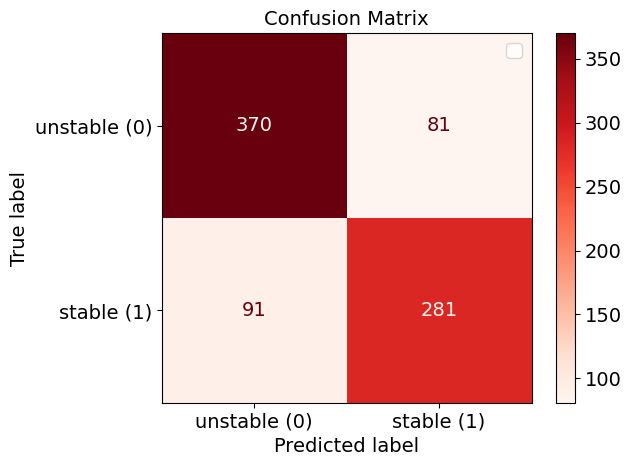

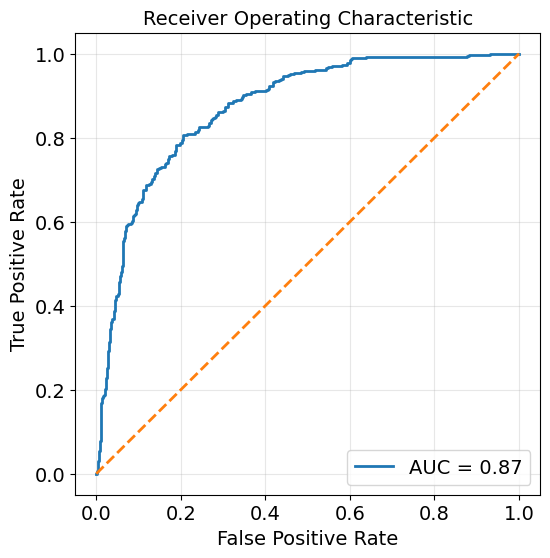


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

unstable (0)       0.80      0.82      0.81       451
  stable (1)       0.78      0.76      0.77       372

    accuracy                           0.79       823
   macro avg       0.79      0.79      0.79       823
weighted avg       0.79      0.79      0.79       823



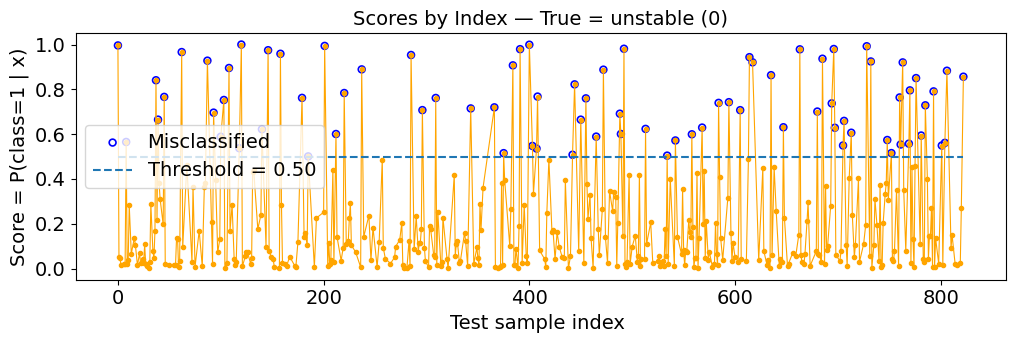

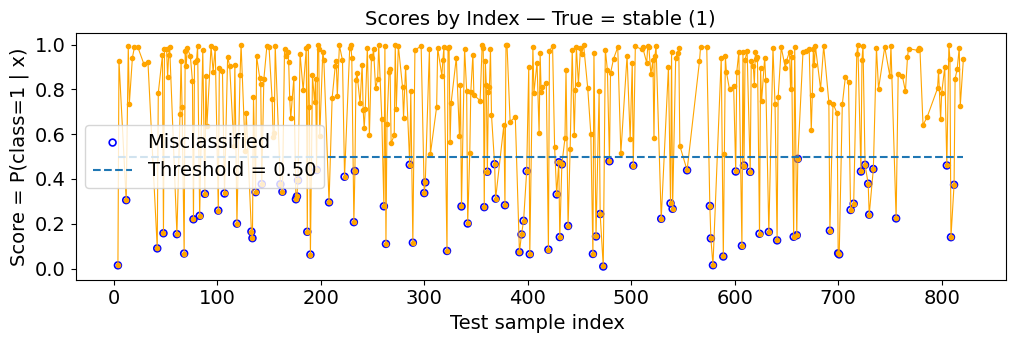

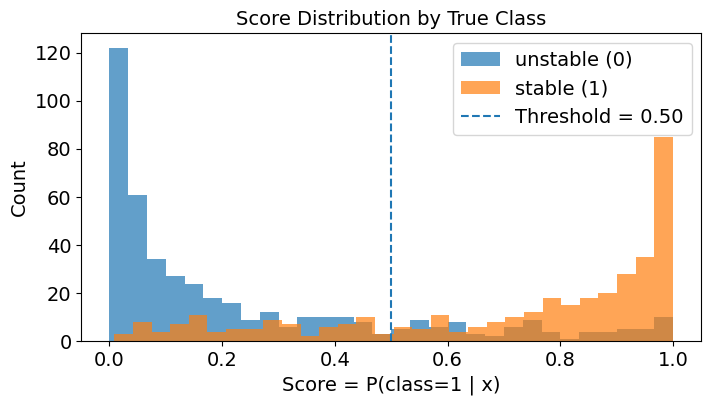

Device: Apple Metal GPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Number of audio recordings: 8229
PCA feature extraction time: 41.13 seconds
Average PCA time per audio: 4.9978 ms
Model training time: 14.96 seconds
Total PCA + model training time: 56.09 seconds
Model-only mean inference latency: 0.4146 ms
Model-only P95 inference latency: 0.7345 ms
Estimated end-to-end mean inference latency: 5.4124 ms
Estimated end-to-end P95 inference latency: 5.7322 ms
Estimated end-to-end throughput: 184.76 samples/second
Real-time limit: 100.00 ms
Estimated end-to-end real-time feasible: True


In [41]:
torch.manual_seed(42)
np.random.seed(42)
BEST_EV_PCT = 96
BEST_MODEL_NAME = "MLP (2-layer)"
BEST_HIDDEN = 128
device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
pretty_to_ctor = {
    "MLP (1-layer)":"MLP",
    "MLP (2-layer)":"MLP_2_layer",
    "MLP (3-layer)":"MLP_3_layer"
}
ctor_to_tag = {
    "MLP":"mlp1",
    "MLP_2_layer":"mlp2",
    "MLP_3_layer":"mlp3"
}
ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag = ctor_to_tag[ctor_name]
model_name = f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN"
model_dir = "./final_model_paths"
os.makedirs(model_dir,exist_ok=True)
model_path = os.path.join(model_dir,f"{model_name}.pth")

# ----------------- PCA DATASET + PCA TIME -----------------
best_ev = BEST_EV_PCT/100.0
pca_start = time.perf_counter()
P2_PCA_best = Extract_Features(
    P2_df_X,
    P2_df_Y,
    feature="pca",
    explained_variance=best_ev
)
pca_feature_extraction_time_sec = time.perf_counter()-pca_start
num_audio_samples = len(P2_df_X)
pca_time_per_audio_ms = (pca_feature_extraction_time_sec/num_audio_samples)*1000
y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx,test_idx = train_test_split(
    idx_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)
train_ds = Subset(P2_PCA_best,train_idx.tolist())
test_ds = Subset(P2_PCA_best,test_idx.tolist())
batch_size = 30
train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,drop_last=False)
test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,drop_last=False)
X_best = P2_PCA_best.get_samples()
input_dim = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)
common_kwargs = {
    "nb_hidden":int(BEST_HIDDEN),
    "input_dim":int(input_dim),
    "output_dim":int(num_classes),
    "dropout_rate":0.2
}
model_ctor = globals().get(ctor_name,getattr(classify,ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- MODEL TRAINING TIME -----------------
epochs = 20
train_start = time.perf_counter()
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs
    )
model_training_time_sec = time.perf_counter()-train_start
total_training_time_sec = pca_feature_extraction_time_sec+model_training_time_sec

# ----------------- TEST -----------------
test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str,
    threshold_viz=True
)
acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]
cohen_kappa = test_results["cohen_kappa"]

# ----------------- END-TO-END INFERENCE -----------------
device_info = get_device_info(device_str)
device = torch.device(device_str)
model = model.to(device)
model.eval()
warmup_runs = 50
timed_runs = 300
batch = next(iter(test_loader))
batch_x = get_batch_inputs(batch)
if not torch.is_tensor(batch_x):
    batch_x = torch.tensor(batch_x,dtype=torch.float32)
batch_x = batch_x.float().reshape(batch_x.shape[0],-1).to(device)
single_x = batch_x[:1]
with torch.inference_mode():
    for _ in range(warmup_runs):
        _ = model(single_x)
    synchronize_device(device)
    model_single_times_ms = []
    for _ in range(timed_runs):
        synchronize_device(device)
        inference_start = time.perf_counter()
        _ = model(single_x)
        synchronize_device(device)
        model_single_times_ms.append((time.perf_counter()-inference_start)*1000)
    for _ in range(warmup_runs):
        _ = model(batch_x)
    synchronize_device(device)
    model_batch_times_ms = []
    for _ in range(timed_runs):
        synchronize_device(device)
        inference_start = time.perf_counter()
        _ = model(batch_x)
        synchronize_device(device)
        model_batch_times_ms.append((time.perf_counter()-inference_start)*1000)
model_single_times_ms = np.asarray(model_single_times_ms)
model_batch_times_ms = np.asarray(model_batch_times_ms)
model_only_inference_ms_mean = float(np.mean(model_single_times_ms))
model_only_inference_ms_p95 = float(np.percentile(model_single_times_ms,95))
single_inference_ms_mean = pca_time_per_audio_ms+model_only_inference_ms_mean
single_inference_ms_p95 = pca_time_per_audio_ms+model_only_inference_ms_p95
mean_model_batch_time_sec = np.mean(model_batch_times_ms)/1000
model_only_throughput_samples_sec = float(batch_x.shape[0]/mean_model_batch_time_sec)
throughput_samples_sec = (
    1000/single_inference_ms_mean
    if single_inference_ms_mean > 0
    else np.nan
)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Number of audio recordings: {num_audio_samples}")
print(f"PCA feature extraction time: {pca_feature_extraction_time_sec:.2f} seconds")
print(f"Average PCA time per audio: {pca_time_per_audio_ms:.4f} ms")
print(f"Model training time: {model_training_time_sec:.2f} seconds")
print(f"Total PCA + model training time: {total_training_time_sec:.2f} seconds")
print(f"Model-only mean inference latency: {model_only_inference_ms_mean:.4f} ms")
print(f"Model-only P95 inference latency: {model_only_inference_ms_p95:.4f} ms")
print(f"Estimated end-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"Estimated end-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"Estimated end-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"Estimated end-to-end real-time feasible: {real_time_feasible}")

# ----------------- UPSERT INTO ROC DATAFRAME -----------------
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":BEST_MODEL_NAME,
    "ev_pct":BEST_EV_PCT,
    "hidden":BEST_HIDDEN,
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "pca_feature_extraction_time_sec":pca_feature_extraction_time_sec,
    "pca_time_per_audio_ms":pca_time_per_audio_ms,
    "model_training_time_sec":model_training_time_sec,
    "total_training_time_sec":total_training_time_sec,
    "model_only_inference_ms_mean":model_only_inference_ms_mean,
    "model_only_inference_ms_p95":model_only_inference_ms_p95,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)
if model_name == "mlp2_ev96_h256_P2_RETRAIN":
    roc_df = roc_df[roc_df["model_name"] != "mlp2_ev96_h128_P2_RETRAIN"]
else:
    roc_df = roc_df[roc_df["model_name"] != "mlp2_ev96_h256_P2_RETRAIN"]

In [42]:
pd.set_option("display.max_columns", None)
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible,pca_feature_extraction_time_sec,model_training_time_sec,total_training_time_sec,pca_time_per_audio_ms,model_only_inference_ms_mean,model_only_inference_ms_p95
0,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,41.7307,0.9975,1.5258,57386.5834,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
1,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8420,0.9124,"[0.0, 0.0, 0.0, 0.002145922746781116, 0.002145...","[0.0, 0.0027548209366391185, 0.066115702479338...","[inf, 0.99978274, 0.9897423, 0.9896988, 0.9779...",0.6763,Apple Metal GPU (Apple M3),Apple M3,16.0,40.5771,1.0988,1.2582,32121.3156,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
2,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,NaN,1.0472,1.3171,2327.8885,100.0,True,35.4350,17.3391,52.7741,4.3061,NaN,NaN
3,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7910,0.8728,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 1.0, 0.99959546, 0.9991365, 0.9963076, 0...",0.5771,Apple Metal GPU (Apple M3),Apple M3,16.0,NaN,5.4124,5.7322,184.7619,100.0,True,41.1266,14.9611,56.0877,4.9978,0.4146,0.7345


### PCA MLP Graph

[GRAPH] Saved to: ../assets/march_paper/best_model_mlp2_ev96_h128_P2_RETRAIN.png (and/or .pdf)


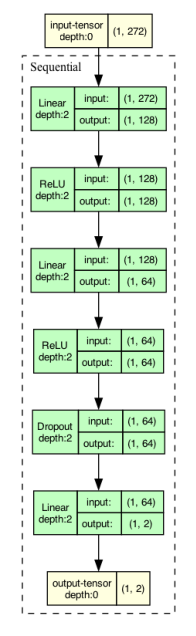

In [ ]:

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/march_paper/best_model_{model_name}"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device="cpu",
    save_graph=True,
    filename=graph_fname,
)


print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

# show graph in notebook
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
img_path = f"{graph_fname}.png"
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(f"Graph image not found at {img_path}")

## PCA + SVM

Accuracy: 0.7886


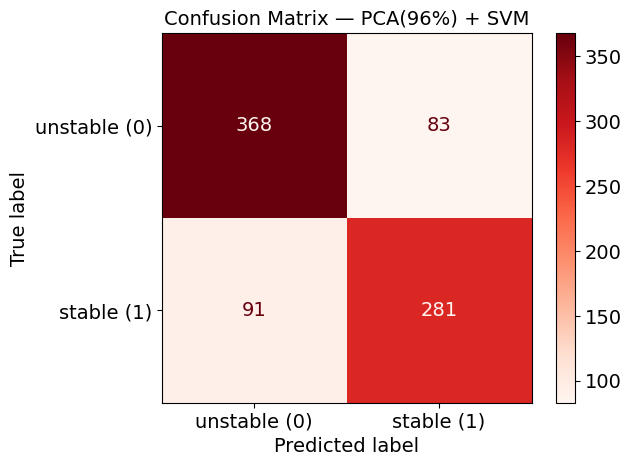


Classification Report:

              precision    recall  f1-score   support

unstable (0)       0.80      0.82      0.81       451
  stable (1)       0.77      0.76      0.76       372

    accuracy                           0.79       823
   macro avg       0.79      0.79      0.79       823
weighted avg       0.79      0.79      0.79       823

ROC AUC: 0.8504


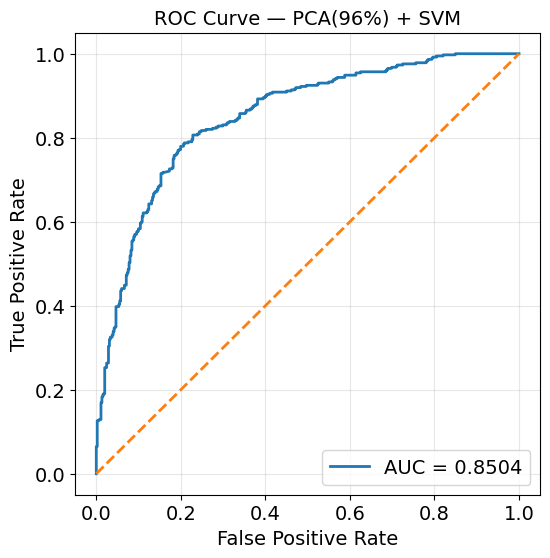

Device: CPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Number of audio recordings: 8229
Scaler + PCA extraction time: 34.60 seconds
Average scaler + PCA time per audio: 4.2041 ms
SVM training time: 17.15 seconds
Total PCA + SVM training time: 51.74 seconds
End-to-end mean inference latency: 0.9320 ms
End-to-end P95 inference latency: 1.1797 ms
End-to-end throughput: 2346.51 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


In [43]:
torch.manual_seed(42)
np.random.seed(42)
BEST_EV_PCT = 96
BEST_MODEL_NAME = "SVM (RBF)"
X = P2_df_X.to_numpy()
y = P2_df_Y.squeeze().astype(int).to_numpy() if hasattr(P2_df_Y,"to_numpy") else P2_df_Y.squeeze().astype(int).values
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
X_train_2d = X_train.reshape(X_train.shape[0],-1)
X_test_2d = X_test.reshape(X_test.shape[0],-1)

# ----------------- SCALER + PCA TIME -----------------
preprocessing_start = time.perf_counter()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)
pca = PCA(n_components=BEST_EV_PCT/100.0,random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_feature_extraction_time_sec = time.perf_counter()-preprocessing_start
num_audio_samples = len(X_train_2d)+len(X_test_2d)
pca_time_per_audio_ms = (pca_feature_extraction_time_sec/num_audio_samples)*1000

# ----------------- SVM TRAINING TIME -----------------
svm_model = SVC(
    kernel="rbf",
    C=100,
    gamma="scale",
    probability=True,
    random_state=42
)
model_train_start = time.perf_counter()
svm_model.fit(X_train_pca,y_train)
model_training_time_sec = time.perf_counter()-model_train_start
total_training_time_sec = pca_feature_extraction_time_sec+model_training_time_sec

# ----------------- TEST -----------------
y_pred = svm_model.predict(X_test_pca)
y_score = svm_model.predict_proba(X_test_pca)[:,1]
acc = accuracy_score(y_test,y_pred)
cohen_kappa = cohen_kappa_score(y_test,y_pred)
print(f"Accuracy: {acc:.4f}")
plt.rcParams.update({"font.size":14})
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["unstable (0)","stable (1)"]
)
disp.plot(cmap="Reds",values_format=".0f")
plt.title(f"Confusion Matrix — PCA({BEST_EV_PCT}%) + SVM",fontsize=14)
plt.xlabel("Predicted label",fontsize=14)
plt.ylabel("True label",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
report = classification_report(
    y_test,
    y_pred,
    target_names=["unstable (0)","stable (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)
fpr,tpr,roc_thresholds = roc_curve(y_test,y_score)
roc_auc = auc(fpr,tpr)
print(f"ROC AUC: {roc_auc:.4f}")
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,lw=2,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],lw=2,linestyle="--")
plt.xlabel("False Positive Rate",fontsize=14)
plt.ylabel("True Positive Rate",fontsize=14)
plt.title(f"ROC Curve — PCA({BEST_EV_PCT}%) + SVM",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right",fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# ----------------- END-TO-END INFERENCE -----------------
warmup_runs = 50
timed_runs = 300
inference_batch_size = min(30,len(X_test_2d))
single_raw_x = X_test_2d[:1]
batch_raw_x = X_test_2d[:inference_batch_size]
for _ in range(warmup_runs):
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = svm_model.predict_proba(single_pca)
single_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = svm_model.predict_proba(single_pca)
    single_times_ms.append((time.perf_counter()-inference_start)*1000)
for _ in range(warmup_runs):
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = svm_model.predict_proba(batch_pca)
batch_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = svm_model.predict_proba(batch_pca)
    batch_times_ms.append((time.perf_counter()-inference_start)*1000)
single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = np.mean(batch_times_ms)/1000
throughput_samples_sec = float(len(batch_raw_x)/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
device_info = get_device_info("cpu")
print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Number of audio recordings: {num_audio_samples}")
print(f"Scaler + PCA extraction time: {pca_feature_extraction_time_sec:.2f} seconds")
print(f"Average scaler + PCA time per audio: {pca_time_per_audio_ms:.4f} ms")
print(f"SVM training time: {model_training_time_sec:.2f} seconds")
print(f"Total PCA + SVM training time: {total_training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")

# ----------------- ROC DATAFRAME -----------------
model_name = f"svm_rbf_pca_ev{BEST_EV_PCT}"
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":BEST_MODEL_NAME,
    "ev_pct":BEST_EV_PCT,
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "pca_feature_extraction_time_sec":pca_feature_extraction_time_sec,
    "pca_time_per_audio_ms":pca_time_per_audio_ms,
    "model_training_time_sec":model_training_time_sec,
    "total_training_time_sec":total_training_time_sec,
    "model_only_inference_ms_mean":np.nan,
    "model_only_inference_ms_p95":np.nan,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

In [38]:
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible,pca_feature_extraction_time_sec,model_training_time_sec,total_training_time_sec,pca_time_per_audio_ms,model_only_inference_ms_mean,model_only_inference_ms_p95
0,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,51.9683,0.9885,1.3794,2383.9269,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,41.7307,0.9975,1.5258,57386.5834,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
2,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8420,0.9124,"[0.0, 0.0, 0.0, 0.002145922746781116, 0.002145...","[0.0, 0.0027548209366391185, 0.066115702479338...","[inf, 0.99978274, 0.9897423, 0.9896988, 0.9779...",0.6763,Apple Metal GPU (Apple M3),Apple M3,16.0,40.5771,1.0988,1.2582,32121.3156,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
3,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7825,0.8644,"[0.0, 0.0, 0.0022172949002217295, 0.0022172949...","[0.0, 0.002688172043010753, 0.0026881720430107...","[inf, 0.9996908, 0.99960464, 0.9995796, 0.9988...",0.5596,Apple Metal GPU (Apple M3),Apple M3,16.0,NaN,5.4673,5.8175,182.9041,100.0,True,41.455,14.9682,56.4232,5.0377,0.4297,0.7798


## PCA + XGB


Accuracy: 0.8068


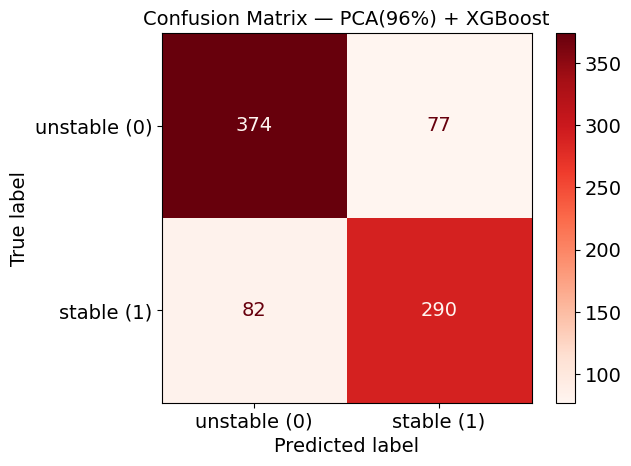


Classification Report:

              precision    recall  f1-score   support

unstable (0)       0.82      0.83      0.82       451
  stable (1)       0.79      0.78      0.78       372

    accuracy                           0.81       823
   macro avg       0.81      0.80      0.80       823
weighted avg       0.81      0.81      0.81       823

ROC AUC: 0.8842


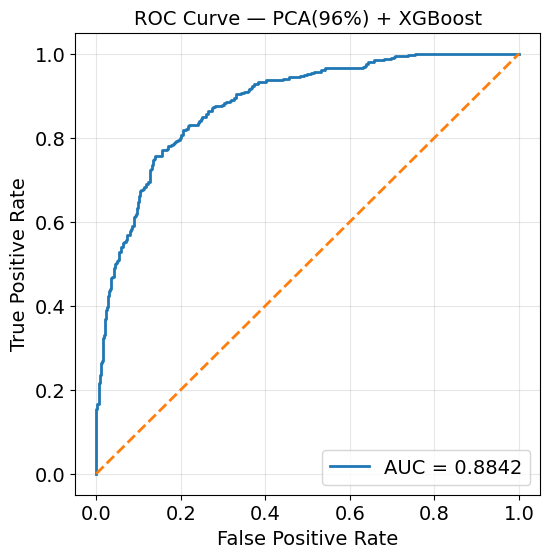

Device: CPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Number of audio recordings: 8229
Scaler + PCA preprocessing time: 34.61 seconds
Average scaler + PCA preprocessing time per audio: 4.2053 ms
XGBoost training time: 5.94 seconds
Total preprocessing + XGBoost training time: 40.55 seconds
End-to-end mean inference latency: 0.6871 ms
End-to-end P95 inference latency: 1.1527 ms
End-to-end throughput: 26845.01 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


In [44]:
torch.manual_seed(42)
np.random.seed(42)
BEST_EV_PCT = 96
BEST_MODEL_NAME = "XGBoost"
X = P2_df_X.to_numpy()
y = P2_df_Y.squeeze().astype(int).to_numpy() if hasattr(P2_df_Y,"to_numpy") else P2_df_Y.squeeze().astype(int).values
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
X_train_2d = X_train.reshape(X_train.shape[0],-1)
X_test_2d = X_test.reshape(X_test.shape[0],-1)

# ----------------- SCALER + PCA PREPROCESSING -----------------
preprocessing_start = time.perf_counter()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)
pca = PCA(
    n_components=BEST_EV_PCT/100.0,
    random_state=42
)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_feature_extraction_time_sec = time.perf_counter()-preprocessing_start
num_audio_samples = len(X_train_2d)+len(X_test_2d)
pca_time_per_audio_ms = (pca_feature_extraction_time_sec/num_audio_samples)*1000

# ----------------- XGBOOST TRAINING -----------------
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
model_train_start = time.perf_counter()
xgb_model.fit(X_train_pca,y_train)
model_training_time_sec = time.perf_counter()-model_train_start
total_training_time_sec = pca_feature_extraction_time_sec+model_training_time_sec

# ----------------- TEST -----------------
y_pred = xgb_model.predict(X_test_pca)
y_score = xgb_model.predict_proba(X_test_pca)[:,1]
acc = accuracy_score(y_test,y_pred)
cohen_kappa = cohen_kappa_score(y_test,y_pred)
print(f"Accuracy: {acc:.4f}")
plt.rcParams.update({"font.size":14})
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["unstable (0)","stable (1)"]
)
disp.plot(cmap="Reds",values_format=".0f")
plt.title(f"Confusion Matrix — PCA({BEST_EV_PCT}%) + XGBoost",fontsize=14)
plt.xlabel("Predicted label",fontsize=14)
plt.ylabel("True label",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
report = classification_report(
    y_test,
    y_pred,
    target_names=["unstable (0)","stable (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)
fpr,tpr,roc_thresholds = roc_curve(y_test,y_score)
roc_auc = auc(fpr,tpr)
print(f"ROC AUC: {roc_auc:.4f}")
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,lw=2,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],lw=2,linestyle="--")
plt.xlabel("False Positive Rate",fontsize=14)
plt.ylabel("True Positive Rate",fontsize=14)
plt.title(f"ROC Curve — PCA({BEST_EV_PCT}%) + XGBoost",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right",fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# ----------------- END-TO-END INFERENCE -----------------
warmup_runs = 50
timed_runs = 300
inference_batch_size = min(30,len(X_test_2d))
single_raw_x = X_test_2d[:1]
batch_raw_x = X_test_2d[:inference_batch_size]

for _ in range(warmup_runs):
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = xgb_model.predict_proba(single_pca)

single_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = xgb_model.predict_proba(single_pca)
    single_times_ms.append((time.perf_counter()-inference_start)*1000)

for _ in range(warmup_runs):
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = xgb_model.predict_proba(batch_pca)

batch_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = xgb_model.predict_proba(batch_pca)
    batch_times_ms.append((time.perf_counter()-inference_start)*1000)

single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = float(np.mean(batch_times_ms)/1000)
throughput_samples_sec = float(len(batch_raw_x)/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
device_info = get_device_info("cpu")

print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Number of audio recordings: {num_audio_samples}")
print(f"Scaler + PCA preprocessing time: {pca_feature_extraction_time_sec:.2f} seconds")
print(f"Average scaler + PCA preprocessing time per audio: {pca_time_per_audio_ms:.4f} ms")
print(f"XGBoost training time: {model_training_time_sec:.2f} seconds")
print(f"Total preprocessing + XGBoost training time: {total_training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")

# ----------------- ROC DATAFRAME -----------------
model_name = f"xgboost_pca_ev{BEST_EV_PCT}"
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":BEST_MODEL_NAME,
    "ev_pct":BEST_EV_PCT,
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "pca_feature_extraction_time_sec":pca_feature_extraction_time_sec,
    "pca_time_per_audio_ms":pca_time_per_audio_ms,
    "model_training_time_sec":model_training_time_sec,
    "total_training_time_sec":total_training_time_sec,
    "model_only_inference_ms_mean":np.nan,
    "model_only_inference_ms_p95":np.nan,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

## PCA + Random Forest

Accuracy: 0.7643


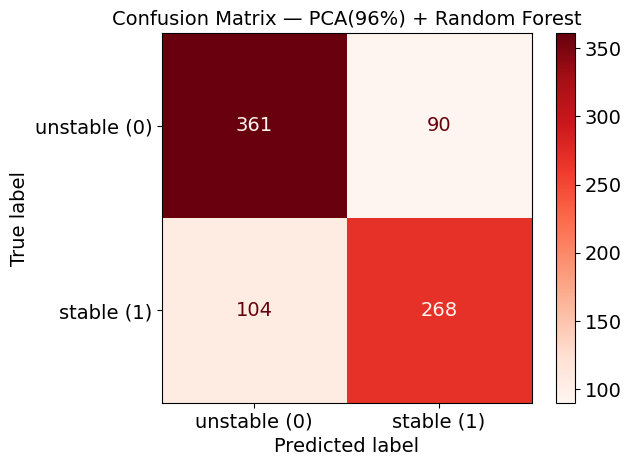


Classification Report:

              precision    recall  f1-score   support

unstable (0)       0.78      0.80      0.79       451
  stable (1)       0.75      0.72      0.73       372

    accuracy                           0.76       823
   macro avg       0.76      0.76      0.76       823
weighted avg       0.76      0.76      0.76       823

ROC AUC: 0.8431


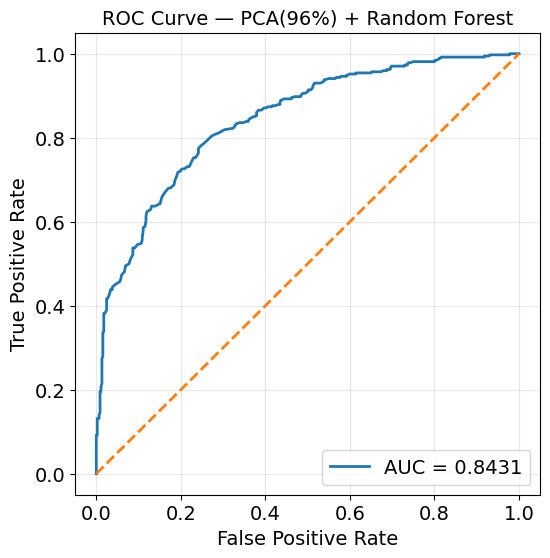

Device: CPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Number of audio recordings: 8229
Scaler + PCA preprocessing time: 39.02 seconds
Average scaler + PCA preprocessing time per audio: 4.7423 ms
Random Forest training time: 23.90 seconds
Total preprocessing + Random Forest training time: 62.92 seconds
End-to-end mean inference latency: 40.2656 ms
End-to-end P95 inference latency: 43.6418 ms
End-to-end throughput: 571.09 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


/var/folders/nh/9fsl45m17nn6q_xt_zd0wwbw0000gn/T/ipykernel_6477/2653828018.py:174: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  roc_df = pd.concat([roc_df,new_row],ignore_index=True)


In [16]:
torch.manual_seed(42)
np.random.seed(42)
BEST_EV_PCT = 96
BEST_MODEL_NAME = "Random Forest"
X = P2_df_X.to_numpy()
y = P2_df_Y.squeeze().astype(int).to_numpy() if hasattr(P2_df_Y,"to_numpy") else P2_df_Y.squeeze().astype(int).values
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
X_train_2d = X_train.reshape(X_train.shape[0],-1)
X_test_2d = X_test.reshape(X_test.shape[0],-1)

# ----------------- SCALER + PCA PREPROCESSING -----------------
preprocessing_start = time.perf_counter()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)
pca = PCA(
    n_components=BEST_EV_PCT/100.0,
    random_state=42
)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_feature_extraction_time_sec = time.perf_counter()-preprocessing_start
num_audio_samples = len(X_train_2d)+len(X_test_2d)
pca_time_per_audio_ms = (pca_feature_extraction_time_sec/num_audio_samples)*1000

# ----------------- RANDOM FOREST TRAINING -----------------
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)
model_train_start = time.perf_counter()
rf_model.fit(X_train_pca,y_train)
model_training_time_sec = time.perf_counter()-model_train_start
total_training_time_sec = pca_feature_extraction_time_sec+model_training_time_sec

# ----------------- TEST -----------------
y_pred = rf_model.predict(X_test_pca)
y_score = rf_model.predict_proba(X_test_pca)[:,1]
acc = accuracy_score(y_test,y_pred)
cohen_kappa = cohen_kappa_score(y_test,y_pred)
print(f"Accuracy: {acc:.4f}")
plt.rcParams.update({"font.size":14})
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["unstable (0)","stable (1)"]
)
disp.plot(cmap="Reds",values_format=".0f")
plt.title(f"Confusion Matrix — PCA({BEST_EV_PCT}%) + Random Forest",fontsize=14)
plt.xlabel("Predicted label",fontsize=14)
plt.ylabel("True label",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
report = classification_report(
    y_test,
    y_pred,
    target_names=["unstable (0)","stable (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)
fpr,tpr,roc_thresholds = roc_curve(y_test,y_score)
roc_auc = auc(fpr,tpr)
print(f"ROC AUC: {roc_auc:.4f}")
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,lw=2,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],lw=2,linestyle="--")
plt.xlabel("False Positive Rate",fontsize=14)
plt.ylabel("True Positive Rate",fontsize=14)
plt.title(f"ROC Curve — PCA({BEST_EV_PCT}%) + Random Forest",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right",fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# ----------------- END-TO-END INFERENCE -----------------
warmup_runs = 50
timed_runs = 300
inference_batch_size = min(30,len(X_test_2d))
single_raw_x = X_test_2d[:1]
batch_raw_x = X_test_2d[:inference_batch_size]

for _ in range(warmup_runs):
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = rf_model.predict_proba(single_pca)

single_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    single_scaled = scaler.transform(single_raw_x)
    single_pca = pca.transform(single_scaled)
    _ = rf_model.predict_proba(single_pca)
    single_times_ms.append((time.perf_counter()-inference_start)*1000)

for _ in range(warmup_runs):
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = rf_model.predict_proba(batch_pca)

batch_times_ms = []
for _ in range(timed_runs):
    inference_start = time.perf_counter()
    batch_scaled = scaler.transform(batch_raw_x)
    batch_pca = pca.transform(batch_scaled)
    _ = rf_model.predict_proba(batch_pca)
    batch_times_ms.append((time.perf_counter()-inference_start)*1000)

single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = float(np.mean(batch_times_ms)/1000)
throughput_samples_sec = float(len(batch_raw_x)/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
device_info = get_device_info("cpu")

print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Number of audio recordings: {num_audio_samples}")
print(f"Scaler + PCA preprocessing time: {pca_feature_extraction_time_sec:.2f} seconds")
print(f"Average scaler + PCA preprocessing time per audio: {pca_time_per_audio_ms:.4f} ms")
print(f"Random Forest training time: {model_training_time_sec:.2f} seconds")
print(f"Total preprocessing + Random Forest training time: {total_training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")

# ----------------- ROC DATAFRAME -----------------
model_name = f"random_forest_pca_ev{BEST_EV_PCT}"
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":BEST_MODEL_NAME,
    "ev_pct":BEST_EV_PCT,
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "pca_feature_extraction_time_sec":pca_feature_extraction_time_sec,
    "pca_time_per_audio_ms":pca_time_per_audio_ms,
    "model_training_time_sec":model_training_time_sec,
    "total_training_time_sec":total_training_time_sec,
    "model_only_inference_ms_mean":np.nan,
    "model_only_inference_ms_p95":np.nan,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

In [47]:
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible,pca_feature_extraction_time_sec,model_training_time_sec,total_training_time_sec,pca_time_per_audio_ms,model_only_inference_ms_mean,model_only_inference_ms_p95
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7910,0.8728,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 1.0, 0.99959546, 0.9991365, 0.9963076, 0...",0.5771,Apple Metal GPU (Apple M3),Apple M3,16.0,NaN,5.4124,5.7322,184.7619,100.0,True,41.1266,14.9611,56.0877,4.9978,0.4146,0.7345
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,NaN,0.9320,1.1797,2346.5084,100.0,True,34.5954,17.1466,51.7420,4.2041,NaN,NaN
2,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,NaN,0.6871,1.1527,26845.0136,100.0,True,34.6052,5.9447,40.5498,4.2053,NaN,NaN
3,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8615,0.9417,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.2473118279569892...","[inf, 0.9977071, 0.95895135, 0.9587408, 0.9567...",0.7188,Apple Metal GPU (Apple M3),Apple M3,16.0,33.8842,1.3227,2.2823,30251.6628,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN


# Deep Learning Experiments

## End-to-End ResNet

torch.Size([4800])
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.8615


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/models/loops.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


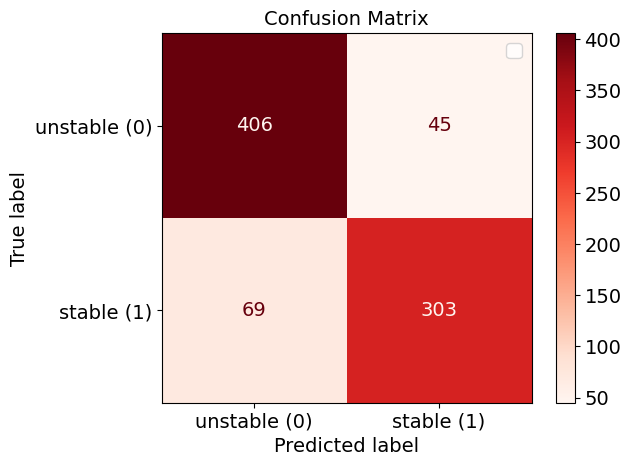

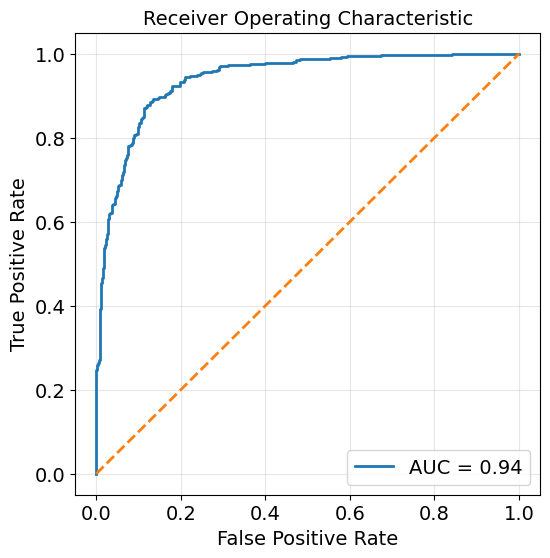


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

unstable (0)       0.85      0.90      0.88       451
  stable (1)       0.87      0.81      0.84       372

    accuracy                           0.86       823
   macro avg       0.86      0.86      0.86       823
weighted avg       0.86      0.86      0.86       823



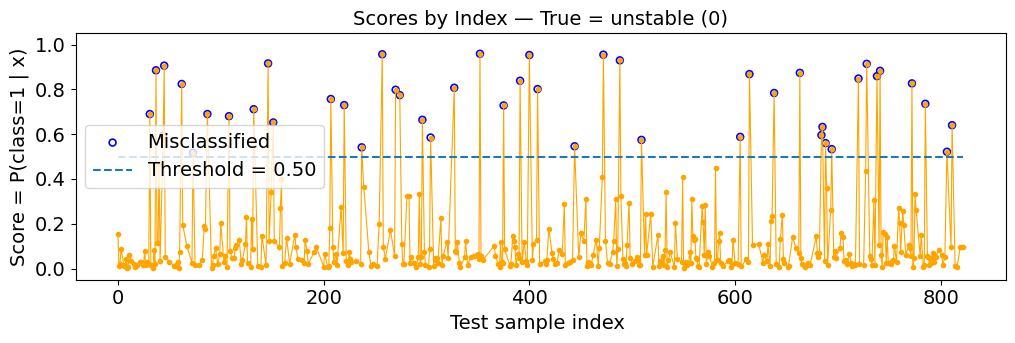

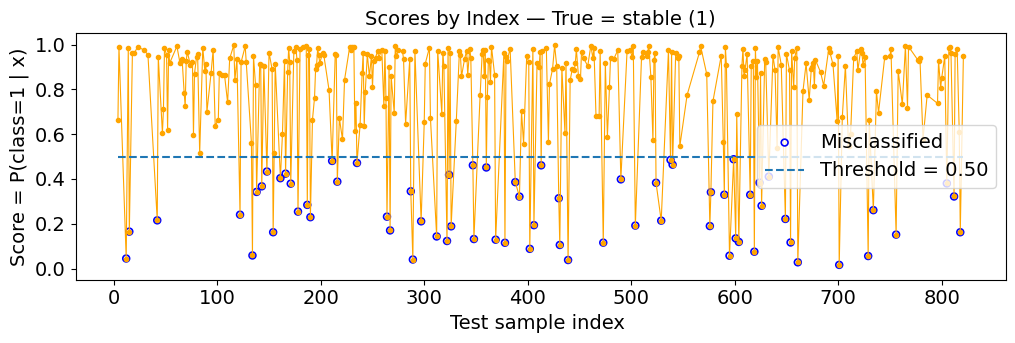

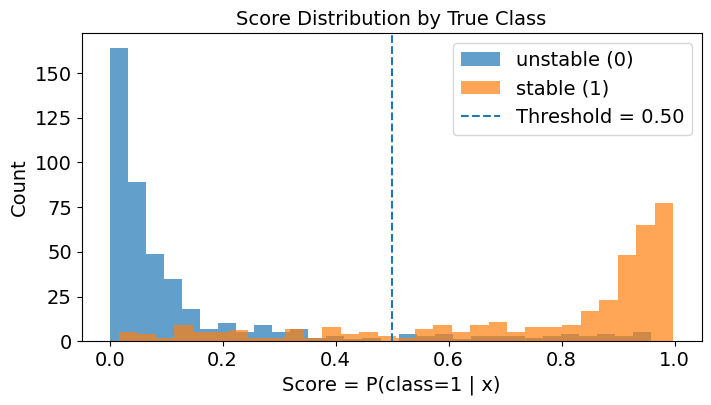

Accuracy: 0.8615
ROC AUC: 0.9417
Device: Apple Metal GPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Training time: 33.88 seconds
End-to-end mean inference latency: 1.3227 ms
End-to-end P95 inference latency: 2.2823 ms
End-to-end throughput: 30251.66 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


In [46]:
device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_NAME = "ResNet (End-to-End)"
model_name = "resnet_end_to_end_p2_retrain"
model_dir = "./model_paths"
os.makedirs(model_dir,exist_ok=True)
model_path = os.path.join(model_dir,"raw_p2_conv.pth")
train_data = torch.utils.data.Subset(P2_raw,train_idx)
test_data = torch.utils.data.Subset(P2_raw,test_idx)
batch_size = 90
train_loader = torch.utils.data.DataLoader(train_data,batch_size=batch_size,shuffle=True,drop_last=False)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=batch_size,shuffle=False,drop_last=False)
print(train_loader.dataset[0][0].shape)
epochs = 20
model = models.Convolution_p2()
train_start = time.perf_counter()
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=1e-3,
        optim="adam",
        epochs=epochs
    )
training_time_sec = time.perf_counter()-train_start
test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str,
    threshold_viz=True
)
acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]
cohen_kappa = test_results["cohen_kappa"]

# ----------------- END-TO-END INFERENCE -----------------
device_info = get_device_info(device_str)
device = torch.device(device_str)
model = model.to(device)
model.eval()
warmup_runs = 50
timed_runs = 300
batch = next(iter(test_loader))
if isinstance(batch,(tuple,list)):
    batch_x = batch[0]
elif isinstance(batch,dict):
    batch_x = next(batch[key] for key in ["x","X","input","inputs","features"] if key in batch)
else:
    batch_x = batch
if not torch.is_tensor(batch_x):
    batch_x = torch.tensor(batch_x,dtype=torch.float32)
batch_x = batch_x.float().to(device)
single_x = batch_x[:1]
with torch.inference_mode():
    for _ in range(warmup_runs):
        _ = model(single_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    single_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(single_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        single_times_ms.append((time.perf_counter()-inference_start)*1000)
    for _ in range(warmup_runs):
        _ = model(batch_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    batch_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(batch_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        batch_times_ms.append((time.perf_counter()-inference_start)*1000)
single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = float(np.mean(batch_times_ms)/1000)
throughput_samples_sec = float(batch_x.shape[0]/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Training time: {training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":MODEL_NAME,
    "ev_pct":"-",
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "training_time_sec":training_time_sec,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

In [32]:
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7825,0.8533,"[0.0, 0.0, 0.0, 0.004434589800443459, 0.004434...","[0.0, 0.002688172043010753, 0.0107526881720430...","[inf, 0.9993381, 0.99812716, 0.9968747, 0.9918...",0.5590,Apple Metal GPU (Apple M3),Apple M3,16.0,17.7375,0.3780,0.4914,79465.1430,100.0,True
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,51.9683,0.9885,1.3794,2383.9269,100.0,True
2,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,41.7307,0.9975,1.5258,57386.5834,100.0,True
3,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8420,0.9124,"[0.0, 0.0, 0.0, 0.002145922746781116, 0.002145...","[0.0, 0.0027548209366391185, 0.066115702479338...","[inf, 0.99978274, 0.9897423, 0.9896988, 0.9779...",0.6763,Apple Metal GPU (Apple M3),Apple M3,16.0,40.5771,1.0988,1.2582,32121.3156,100.0,True


## MFCC + MLP

torch.Size([4800])
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.8967


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/models/loops.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


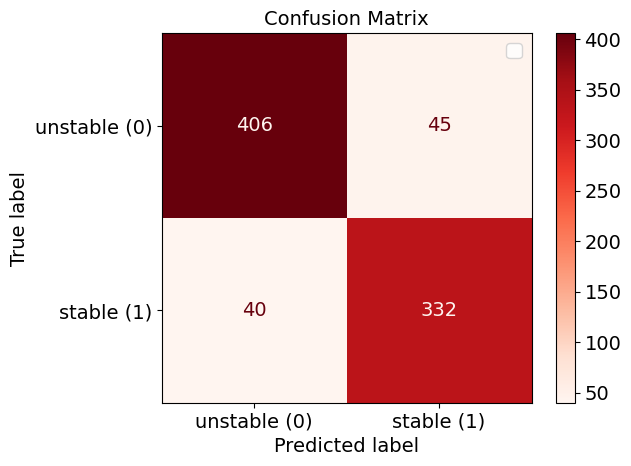

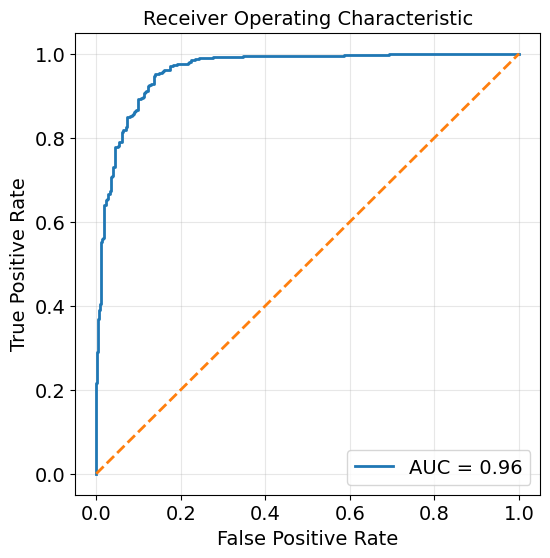


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

unstable (0)       0.91      0.90      0.91       451
  stable (1)       0.88      0.89      0.89       372

    accuracy                           0.90       823
   macro avg       0.90      0.90      0.90       823
weighted avg       0.90      0.90      0.90       823



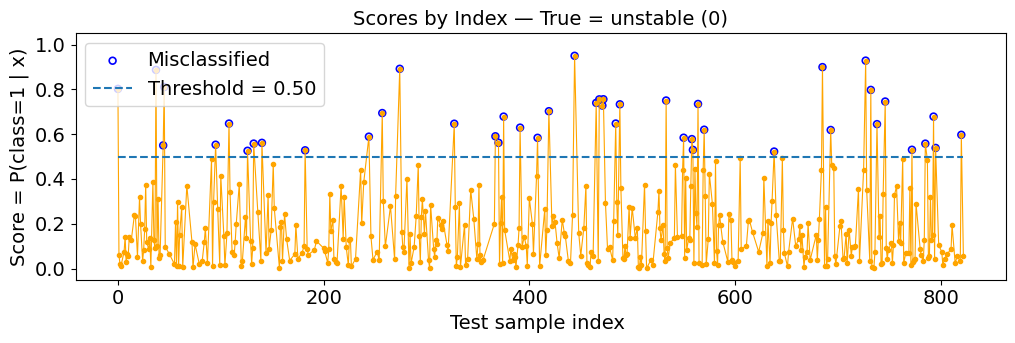

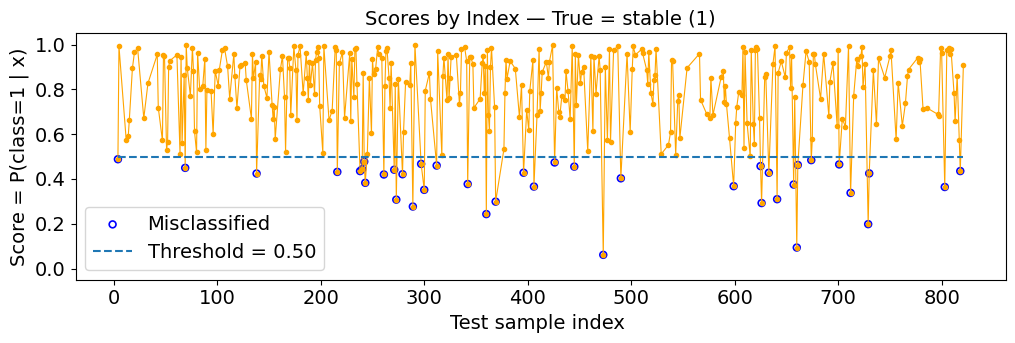

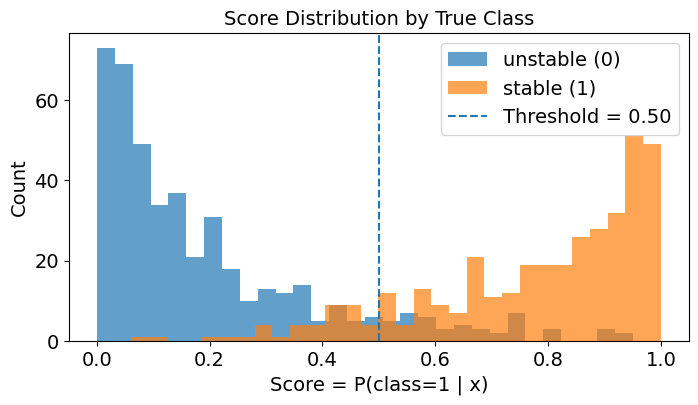

Accuracy: 0.8967
ROC AUC: 0.9625
Device: Apple Metal GPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Training time: 11.03 seconds
End-to-end mean inference latency: 0.9559 ms
End-to-end P95 inference latency: 1.6182 ms
End-to-end throughput: 101669.26 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


In [50]:
torch.manual_seed(42)
np.random.seed(42)
device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_NAME = "MFCC + MLP (End-to-End)"
model_name = "mfcc_mlp_end_to_end_p2_retrain"
model_dir = "./final_model_paths"
os.makedirs(model_dir,exist_ok=True)
model_path = os.path.join(model_dir,"end_mfcc_mlp_p2_test.pth")
train_data = torch.utils.data.Subset(P2_raw,train_idx)
test_data = torch.utils.data.Subset(P2_raw,test_idx)
batch_size = 90
train_loader = torch.utils.data.DataLoader(train_data,batch_size=batch_size,shuffle=True,drop_last=False)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=batch_size,shuffle=False,drop_last=False)
print(train_loader.dataset[0][0].shape)
epochs = 20
model = models.MFCC()
train_start = time.perf_counter()
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs
    )
training_time_sec = time.perf_counter()-train_start
test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str,
    threshold_viz=True
)
acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]
cohen_kappa = test_results["cohen_kappa"]
device_info = get_device_info(device_str)
device = torch.device(device_str)
model = model.to(device)
model.eval()
warmup_runs = 50
timed_runs = 300
batch = next(iter(test_loader))
if isinstance(batch,(tuple,list)):
    batch_x = batch[0]
elif isinstance(batch,dict):
    batch_x = next(batch[key] for key in ["x","X","input","inputs","features"] if key in batch)
else:
    batch_x = batch
if not torch.is_tensor(batch_x):
    batch_x = torch.tensor(batch_x,dtype=torch.float32)
batch_x = batch_x.float().to(device)
single_x = batch_x[:1]
with torch.inference_mode():
    for _ in range(warmup_runs):
        _ = model(single_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    single_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(single_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        single_times_ms.append((time.perf_counter()-inference_start)*1000)
    for _ in range(warmup_runs):
        _ = model(batch_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    batch_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(batch_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        batch_times_ms.append((time.perf_counter()-inference_start)*1000)
single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = float(np.mean(batch_times_ms)/1000)
throughput_samples_sec = float(batch_x.shape[0]/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Training time: {training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":MODEL_NAME,
    "ev_pct":"-",
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "training_time_sec":training_time_sec,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

In [53]:
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible,pca_feature_extraction_time_sec,model_training_time_sec,total_training_time_sec,pca_time_per_audio_ms,model_only_inference_ms_mean,model_only_inference_ms_p95
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7910,0.8728,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 1.0, 0.99959546, 0.9991365, 0.9963076, 0...",0.5771,Apple Metal GPU (Apple M3),Apple M3,16.0,NaN,5.4124,5.7322,184.7619,100.0,True,41.1266,14.9611,56.0877,4.9978,0.4146,0.7345
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,NaN,0.9320,1.1797,2346.5084,100.0,True,34.5954,17.1466,51.7420,4.2041,NaN,NaN
2,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,NaN,0.6871,1.1527,26845.0136,100.0,True,34.6052,5.9447,40.5498,4.2053,NaN,NaN
3,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8615,0.9417,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.2473118279569892...","[inf, 0.9977071, 0.95895135, 0.9587408, 0.9567...",0.7188,Apple Metal GPU (Apple M3),Apple M3,16.0,33.8842,1.3227,2.2823,30251.6628,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,mfcc_mlp_end_to_end_p2_retrain,MFCC + MLP (End-to-End),-,-,0.8967,0.9625,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.2150537634408602...","[inf, 0.99965715, 0.94986176, 0.94966656, 0.92...",0.7918,Apple Metal GPU (Apple M3),Apple M3,16.0,11.0310,0.9559,1.6182,101669.2557,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN


## MFCC + ResNet

torch.Size([4800])
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.9125


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/models/loops.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


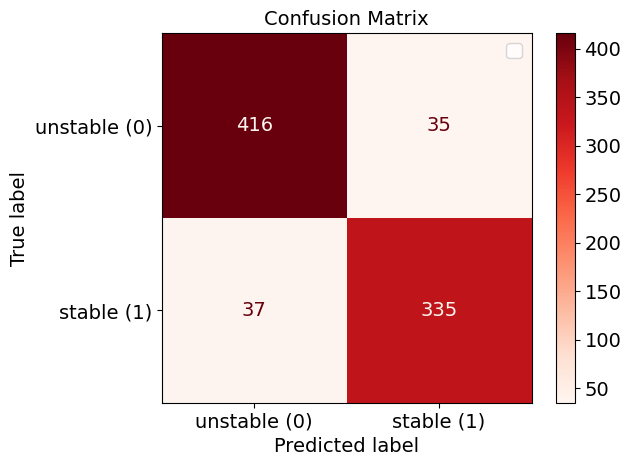

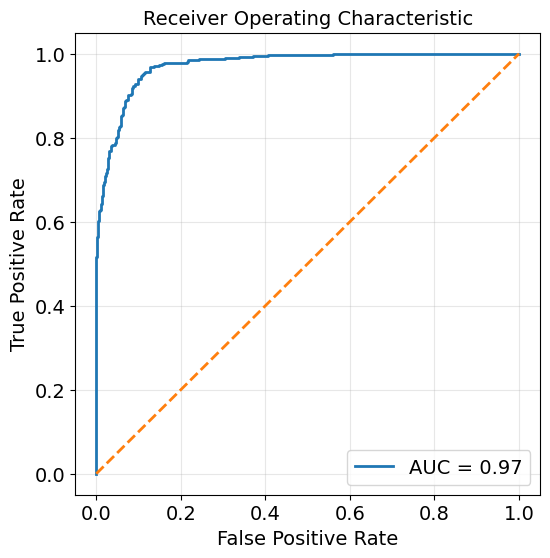


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

unstable (0)       0.92      0.92      0.92       451
  stable (1)       0.91      0.90      0.90       372

    accuracy                           0.91       823
   macro avg       0.91      0.91      0.91       823
weighted avg       0.91      0.91      0.91       823



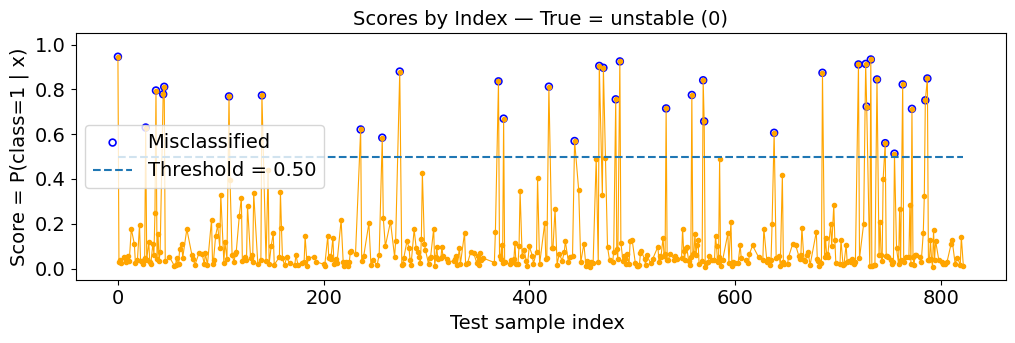

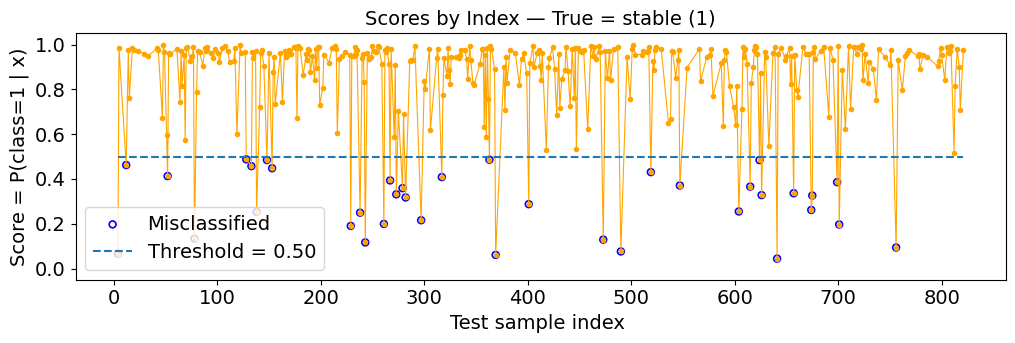

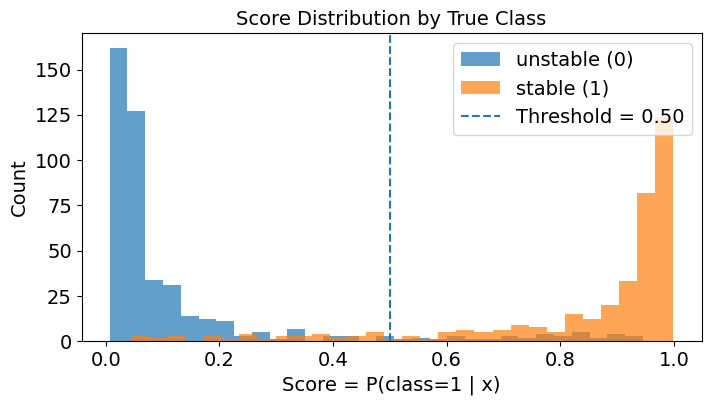

Accuracy: 0.9125
ROC AUC: 0.9737
Device: Apple Metal GPU (Apple M3)
Processor: Apple M3
RAM: 16.0 GB
Training time: 40.10 seconds
End-to-end mean inference latency: 1.3597 ms
End-to-end P95 inference latency: 1.4838 ms
End-to-end throughput: 45428.09 samples/second
Real-time limit: 100.00 ms
End-to-end real-time feasible: True


In [54]:
torch.manual_seed(42)
np.random.seed(42)
device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_NAME = "Resnet + MFCC (End-to-End)"
model_name = "resnet_mfcc_end_to_end_p2_retrain"
model_dir = "./final_model_paths"
os.makedirs(model_dir,exist_ok=True)
model_path = os.path.join(model_dir,"resnet_mfcc_p2_test.pth")
train_data = torch.utils.data.Subset(P2_raw,train_idx)
test_data = torch.utils.data.Subset(P2_raw,test_idx)
batch_size = 90
train_loader = torch.utils.data.DataLoader(train_data,batch_size=batch_size,shuffle=True,drop_last=False)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=batch_size,shuffle=False,drop_last=False)
print(train_loader.dataset[0][0].shape)
epochs = 20
model = models.ConvPlusMFCC()
train_start = time.perf_counter()
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs
    )
training_time_sec = time.perf_counter()-train_start
test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str,
    threshold_viz=True
)
acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]
cohen_kappa = test_results["cohen_kappa"]
device_info = get_device_info(device_str)
device = torch.device(device_str)
model = model.to(device)
model.eval()
warmup_runs = 50
timed_runs = 300
batch = next(iter(test_loader))
if isinstance(batch,(tuple,list)):
    batch_x = batch[0]
elif isinstance(batch,dict):
    batch_x = next(batch[key] for key in ["x","X","input","inputs","features"] if key in batch)
else:
    batch_x = batch
if not torch.is_tensor(batch_x):
    batch_x = torch.tensor(batch_x,dtype=torch.float32)
batch_x = batch_x.float().to(device)
single_x = batch_x[:1]
with torch.inference_mode():
    for _ in range(warmup_runs):
        _ = model(single_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    single_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(single_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        single_times_ms.append((time.perf_counter()-inference_start)*1000)
    for _ in range(warmup_runs):
        _ = model(batch_x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    batch_times_ms = []
    for _ in range(timed_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        inference_start = time.perf_counter()
        _ = model(batch_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        batch_times_ms.append((time.perf_counter()-inference_start)*1000)
single_times_ms = np.asarray(single_times_ms)
batch_times_ms = np.asarray(batch_times_ms)
single_inference_ms_mean = float(np.mean(single_times_ms))
single_inference_ms_p95 = float(np.percentile(single_times_ms,95))
mean_batch_inference_sec = float(np.mean(batch_times_ms)/1000)
throughput_samples_sec = float(batch_x.shape[0]/mean_batch_inference_sec)
REAL_TIME_LIMIT_MS = 100.0
real_time_feasible = single_inference_ms_p95 < REAL_TIME_LIMIT_MS
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Device: {device_info['device_name']}")
print(f"Processor: {device_info['processor']}")
print(f"RAM: {device_info['ram_gb']} GB")
print(f"Training time: {training_time_sec:.2f} seconds")
print(f"End-to-end mean inference latency: {single_inference_ms_mean:.4f} ms")
print(f"End-to-end P95 inference latency: {single_inference_ms_p95:.4f} ms")
print(f"End-to-end throughput: {throughput_samples_sec:.2f} samples/second")
print(f"Real-time limit: {REAL_TIME_LIMIT_MS:.2f} ms")
print(f"End-to-end real-time feasible: {real_time_feasible}")
new_row = pd.DataFrame([{
    "model_name":model_name,
    "model":MODEL_NAME,
    "ev_pct":"-",
    "hidden":"-",
    "accuracy":acc,
    "roc_auc":roc_auc,
    "fpr":np.array(fpr),
    "tpr":np.array(tpr),
    "roc_thresholds":np.array(roc_thresholds),
    "cohen_kappa":cohen_kappa,
    "device_name":device_info["device_name"],
    "processor":device_info["processor"],
    "ram_gb":device_info["ram_gb"],
    "training_time_sec":training_time_sec,
    "single_inference_ms_mean":single_inference_ms_mean,
    "single_inference_ms_p95":single_inference_ms_p95,
    "throughput_samples_sec":throughput_samples_sec,
    "real_time_limit_ms":REAL_TIME_LIMIT_MS,
    "real_time_feasible":real_time_feasible
}])
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df,new_row],ignore_index=True)

In [55]:
display(roc_df.round(4))

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa,device_name,processor,ram_gb,training_time_sec,single_inference_ms_mean,single_inference_ms_p95,throughput_samples_sec,real_time_limit_ms,real_time_feasible,pca_feature_extraction_time_sec,model_training_time_sec,total_training_time_sec,pca_time_per_audio_ms,model_only_inference_ms_mean,model_only_inference_ms_p95
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.7910,0.8728,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 1.0, 0.99959546, 0.9991365, 0.9963076, 0...",0.5771,Apple Metal GPU (Apple M3),Apple M3,16.0,NaN,5.4124,5.7322,184.7619,100.0,True,41.1266,14.9611,56.0877,4.9978,0.4146,0.7345
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.7886,0.8504,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.5724,CPU (Apple M3),Apple M3,16.0,NaN,0.9320,1.1797,2346.5084,100.0,True,34.5954,17.1466,51.7420,4.2041,NaN,NaN
2,xgboost_pca_ev96,XGBoost,96,-,0.8068,0.8842,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.6096,CPU (Apple M3),Apple M3,16.0,NaN,0.6871,1.1527,26845.0136,100.0,True,34.6052,5.9447,40.5498,4.2053,NaN,NaN
3,resnet_end_to_end_p2_retrain,ResNet (End-to-End),-,-,0.8615,0.9417,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.2473118279569892...","[inf, 0.9977071, 0.95895135, 0.9587408, 0.9567...",0.7188,Apple Metal GPU (Apple M3),Apple M3,16.0,33.8842,1.3227,2.2823,30251.6628,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,mfcc_mlp_end_to_end_p2_retrain,MFCC + MLP (End-to-End),-,-,0.8967,0.9625,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.2150537634408602...","[inf, 0.99965715, 0.94986176, 0.94966656, 0.92...",0.7918,Apple Metal GPU (Apple M3),Apple M3,16.0,11.0310,0.9559,1.6182,101669.2557,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
5,resnet_mfcc_end_to_end_p2_retrain,Resnet + MFCC (End-to-End),-,-,0.9125,0.9737,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.5161290322580645...","[inf, 0.99915826, 0.9455539, 0.9454656, 0.9340...",0.8233,Apple Metal GPU (Apple M3),Apple M3,16.0,40.1021,1.3597,1.4838,45428.0932,100.0,True,NaN,NaN,NaN,NaN,NaN,NaN
